## 统计分析

通过指定统计分析字段，得到每个特征的p_value，所有的p_value计算都是基于Ttest计算。支持指定不同的分组`group`，例如train、val、test等分组统计。

对于两大类不同的特征

1. 离散特征，统计数量以及占比。
2. 连续特征，统计均值、方差。

In [1]:
import pandas as pd
import os
import numpy as np
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

task = get_param_in_cwd('task_column') or 'label'
p_value = get_param_in_cwd('p_value') or 0.05
# 修改成自己临床数据的文件。
test_data = pd.read_csv(get_param_in_cwd('clinic_file'))
stats_columns_settings = get_param_in_cwd('stats_columns')
continuous_columns_settings = get_param_in_cwd('continuous_columns')
mapping_columns_settings = get_param_in_cwd('mapping_columns')
test_data = test_data[[c for c in test_data.columns if c != task]]
# test_data['ID'] = test_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
group_info = pd.read_csv(get_param_in_cwd('label_file'))
group_info['ID'] = group_info['ID'].map(lambda x: os.path.splitext(x)[0])
print_join_info(test_data, group_info)
test_data = pd.merge(test_data, group_info, on='ID', how='inner')
test_data

[2026-02-19 23:55:34 - __init__.py:  60]	INFO	ID特征完全匹配！


,ID,Elapsed time,Gender,Age,Disease duration,Age at onset,Baseline mSASSS score,Number of mSASSS score 0,Number of mSASSS score 1,Number of mSASSS score 2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,label,group
0,白璨瑀202003-202501,57,1,19,10.0,9.0,1.2,11.0,1.0,0.0,...,24.60,54.0,3.63,0.89,0.93,2.14,3.903,2.301,0.000,train
1,白璨瑀202201-202501,36,1,21,12.0,9.0,1.2,11.0,1.0,0.0,...,20.90,25.0,4.09,0.82,0.96,2.42,4.260,2.521,0.000,train
2,边英杰202402-202502,12,0,38,10.0,28.0,1.2,11.0,1.0,0.0,...,2.50,8.0,3.49,0.76,1.19,1.90,2.933,1.597,0.000,train
3,曹骥201407-202401,114,1,19,3.0,16.0,0.0,12.0,0.0,0.0,...,41.40,68.0,3.40,3.74,0.69,1.24,4.928,1.797,2.303,val
4,常怀城201411-201709,33,1,29,2.0,27.0,0.6,11.5,0.5,0.0,...,3.45,4.0,3.04,0.96,0.76,1.97,4.000,2.592,0.000,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,周涣博20230503-20240522,13,1,36,10.0,26.0,2.4,11.0,0.0,1.0,...,3.81,18.0,4.91,1.57,0.81,3.22,6.062,3.975,1.758,test
231,孟庆迁20230918-20250401,19,1,29,3.0,26.0,2.4,12.0,0.0,0.0,...,31.30,21.0,5.10,1.12,0.82,3.83,6.220,4.671,1.526,test
232,王绍峰20231222-20241219,12,1,41,17.0,24.0,18.0,6.0,0.0,3.0,...,8.29,29.0,5.46,1.70,0.82,4.22,6.659,5.146,1.224,test
233,富文强20210519-20230301,22,1,40,3.0,37.0,0.0,12.0,0.0,0.0,...,15.50,19.0,4.47,1.64,0.64,3.38,6.984,5.281,1.758,test


In [2]:
test_data['group'].value_counts()

train    134
val       58
test      43
Name: group, dtype: int64

# 特征名称处理

去掉所有特征名称中的特殊字符。

In [3]:
import re

def map_cnames(x):
    x = re.split('[（|(]', x)[0]
    x = x.replace('-', '_').replace(' ', '_').replace('>', '')
    x = x.split('/')[0]
    return x.strip().strip('_')

test_data.columns = list(map(map_cnames, test_data.columns))
test_data.columns

Index(['ID', 'Elapsed_time', 'Gender', 'Age', 'Disease_duration',
       'Age_at_onset', 'Baseline_mSASSS_score', 'Number_of_mSASSS_score_0',
       'Number_of_mSASSS_score_1', 'Number_of_mSASSS_score_2',
       'Number_of_mSASSS_score_3', 'Uveitis', 'Psoriasis',
       'Inflammatory_bowel_disease', 'Peripheral_arthritis', 'Enthesitis',
       'NSAIDs', 'TNF_inhibitor', 'IL17_inhibitor', 'HLA_B27', 'Smoking',
       'Alcoholism', 'CRP', 'ESR', 'Chol', 'TG', 'HDL', 'LDL', 'Chol_HDL',
       'LDL_HDL', 'label', 'group'],
      dtype='object')

# 分析数据

获取待分析的特征列名，如未制定，自动侦测。

In [4]:
stats_columns = [c for c in stats_columns_settings or list(test_data.columns[1:-2]) if c not in ['']]
test_data = test_data.copy()[['ID'] + stats_columns + ['group', task]]
test_data#['group'].value_counts()

,ID,Elapsed_time,Gender,Age,Disease_duration,Age_at_onset,Baseline_mSASSS_score,Number_of_mSASSS_score_0,Number_of_mSASSS_score_1,Number_of_mSASSS_score_2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,group,label
0,白璨瑀202003-202501,57,1,19,10.0,9.0,1.2,11.0,1.0,0.0,...,24.60,54.0,3.63,0.89,0.93,2.14,3.903,2.301,train,0.000
1,白璨瑀202201-202501,36,1,21,12.0,9.0,1.2,11.0,1.0,0.0,...,20.90,25.0,4.09,0.82,0.96,2.42,4.260,2.521,train,0.000
2,边英杰202402-202502,12,0,38,10.0,28.0,1.2,11.0,1.0,0.0,...,2.50,8.0,3.49,0.76,1.19,1.90,2.933,1.597,train,0.000
3,曹骥201407-202401,114,1,19,3.0,16.0,0.0,12.0,0.0,0.0,...,41.40,68.0,3.40,3.74,0.69,1.24,4.928,1.797,val,2.303
4,常怀城201411-201709,33,1,29,2.0,27.0,0.6,11.5,0.5,0.0,...,3.45,4.0,3.04,0.96,0.76,1.97,4.000,2.592,val,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,周涣博20230503-20240522,13,1,36,10.0,26.0,2.4,11.0,0.0,1.0,...,3.81,18.0,4.91,1.57,0.81,3.22,6.062,3.975,test,1.758
231,孟庆迁20230918-20250401,19,1,29,3.0,26.0,2.4,12.0,0.0,0.0,...,31.30,21.0,5.10,1.12,0.82,3.83,6.220,4.671,test,1.526
232,王绍峰20231222-20241219,12,1,41,17.0,24.0,18.0,6.0,0.0,3.0,...,8.29,29.0,5.46,1.70,0.82,4.22,6.659,5.146,test,1.224
233,富文强20210519-20230301,22,1,40,3.0,37.0,0.0,12.0,0.0,0.0,...,15.50,19.0,4.47,1.64,0.64,3.38,6.984,5.281,test,1.758


# 特征队列映射

所有需要进行特征映射的队列，range未制定，可以进行自动判断。

In [5]:
mapping_columns = mapping_columns_settings or [c for c in test_data.columns[1:-2] if test_data[c].dtype == object]
mapping_columns

[]

# 数据映射

针对所有非数值形式的数据，可以进行类别映射。

In [6]:
from onekey_algo.custom.utils import map2numerical

data, mapping = map2numerical(test_data, mapping_columns=mapping_columns)
mapping

{}

# 连续特征列

自动识别所有可能的连续特征列。如果列不是整数，或者列的元素超过5个，则呗认定为连续特征。

In [7]:
from onekey_algo.custom.components.comp1 import fillna

test_data = fillna(test_data, fill_mod='50%')
continuous_columns = []
for col in test_data.columns:
    if test_data[col].apply(lambda x: x.is_integer() if isinstance(x, float) else False).all():
        test_data[col] = test_data[col].astype(int)

for c in stats_columns:
#     print(c, np.unique(test_data[c]), test_data[c].dtype)
    if len(np.unique(test_data[c])) > 15 or not np.int8 <= test_data[c].dtype <= np.int64:
        continuous_columns.append(c)
        
continuous_columns = continuous_columns_settings or continuous_columns
continuous_columns = [c for c in continuous_columns if c not in ('differentation')]
# continuous_columns = []

# 缺失值填充

In [8]:
import os
os.makedirs('data', exist_ok=True)
data = test_data
data.to_csv('data/clinical.csv', index=False, encoding='utf-8-sig')
data

,ID,Elapsed_time,Gender,Age,Disease_duration,Age_at_onset,Baseline_mSASSS_score,Number_of_mSASSS_score_0,Number_of_mSASSS_score_1,Number_of_mSASSS_score_2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,group,label
0,白璨瑀202003-202501,57,1,19,10.0,9.0,1.2,11.0,1.0,0.0,...,24.60,54,3.63,0.89,0.93,2.14,3.903,2.301,train,0.000
1,白璨瑀202201-202501,36,1,21,12.0,9.0,1.2,11.0,1.0,0.0,...,20.90,25,4.09,0.82,0.96,2.42,4.260,2.521,train,0.000
2,边英杰202402-202502,12,0,38,10.0,28.0,1.2,11.0,1.0,0.0,...,2.50,8,3.49,0.76,1.19,1.90,2.933,1.597,train,0.000
3,曹骥201407-202401,114,1,19,3.0,16.0,0.0,12.0,0.0,0.0,...,41.40,68,3.40,3.74,0.69,1.24,4.928,1.797,val,2.303
4,常怀城201411-201709,33,1,29,2.0,27.0,0.6,11.5,0.5,0.0,...,3.45,4,3.04,0.96,0.76,1.97,4.000,2.592,val,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,周涣博20230503-20240522,13,1,36,10.0,26.0,2.4,11.0,0.0,1.0,...,3.81,18,4.91,1.57,0.81,3.22,6.062,3.975,test,1.758
231,孟庆迁20230918-20250401,19,1,29,3.0,26.0,2.4,12.0,0.0,0.0,...,31.30,21,5.10,1.12,0.82,3.83,6.220,4.671,test,1.526
232,王绍峰20231222-20241219,12,1,41,17.0,24.0,18.0,6.0,0.0,3.0,...,8.29,29,5.46,1.70,0.82,4.22,6.659,5.146,test,1.224
233,富文强20210519-20230301,22,1,40,3.0,37.0,0.0,12.0,0.0,0.0,...,15.50,19,4.47,1.64,0.64,3.38,6.984,5.281,test,1.758


### 统计分析

支持两种格式数据，分别对应`pretty`参数的`True`和`False`, 当为`True`时，输出的是表格模式，反之则为dict数据。

```python
def clinic_stats(data: DataFrame, stats_columns: Union[str, List[str]], label_column='label',
                 group_column: str = None, continuous_columns: Union[str, List[str]] = None,
                 pretty: bool = True) -> Union[dict, DataFrame]:
    """

    Args:
        data: 数据
        stats_columns: 需要统计的列名
        label_column: 二分类的标签列，默认`label`
        group_column: 分组统计依据，例如区分训练组、测试组、验证组。
        continuous_columns: 那些列是连续变量，连续变量统计均值方差。
        pretty: bool, 是否对结果进行格式美化。

    Returns:
        stats DataFrame or json

    """
```

In [9]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats_train_val = clinic_stats(data[data['group'].isin(['train', 'val'])], 
                               stats_columns= stats_columns,
                               label_column='group', 
                               group_column=None, 
                               continuous_columns= continuous_columns, 
                               pretty=True, verbose=False).reset_index(drop=True)

stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column='group', 
                     group_column=None, 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
# display(stats)
stats_train_val['test'] = stats['-label=test']
# stats_train_val['test2'] = stats['-label=test2']
stats_train_val.to_csv('data/stats_all.csv', index=False, encoding='utf_8_sig')
stats_train_val

,feature_name,-label=ALL,-label=train,-label=val,pvalue,test
0,Elapsed_time,38.74±29.73,39.12±31.40,37.86±25.69,0.589,19.84±8.90
1,Age,35.97±11.12,35.32±10.76,37.47±11.89,0.403,31.56±8.28
2,Disease_duration,8.93±7.70,9.25±7.61,8.21±7.95,0.183,4.49±4.66
3,Age_at_onset,27.03±9.53,26.07±9.29,29.26±9.78,0.023,27.33±6.83
4,Baseline_mSASSS_score,6.37±10.00,6.18±9.93,6.82±10.22,0.871,2.87±6.53
5,Number_of_mSASSS_score_0,9.31±3.52,9.34±3.51,9.23±3.56,0.972,10.84±2.68
6,Number_of_mSASSS_score_1,0.47±0.68,0.48±0.70,0.43±0.65,0.625,0.28±0.87
7,Number_of_mSASSS_score_2,1.14±1.63,1.09±1.64,1.25±1.61,0.308,0.41±1.03
8,Number_of_mSASSS_score_3,1.05±2.77,1.03±2.84,1.09±2.60,0.753,0.65±2.09
9,NSAIDs,25.40±40.74,28.80±43.56,17.54±32.35,0.018,55.11±41.23


In [10]:
# from onekey_algo.custom.components.stats import clinic_stats

# pd.set_option('display.max_rows', None)
# stats = clinic_stats(data, 
#                      stats_columns= stats_columns,
#                      label_column='group', 
#                      group_column=None, 
#                      continuous_columns= continuous_columns, 
#                      pretty=True, verbose=False)
# stats.to_csv('data/stats_all.csv', index=False, encoding='utf_8_sig')
# stats

# 单因素多因素分析

单因素，步进多因素分析
```python
def uni_multi_variable_analysis(data: pd.DataFrame, features: Union[str, List[str]] = None, label_column: str = 'label',
                                need_norm: Union[bool, List[bool]] = False, alpha=0.1,
                                p_value4multi: float = 0.05, save_dir: Union[str] = None, prefix: str = '',
                                **kwargs):
    """
    单因素，步进多因素分析，使用p_value4multi参数指定多因素分析的阈值
    Args:
        data: 数据
        features: 需要分析的特征，默认除了ID和label_column列，其他的特征都进行分析。
        label_column: 目标列
        need_norm: 是否标准化所有分析的数据, 默认为False
        alpha: CI alpha, alpha/2 %；默认为0.1即95% CI
        p_value4multi: 参数指定多因素分析的阈值，默认为0.05
        save_dir: 保存位置
        prefix: 前缀
        **kwargs:

    Returns:

    """
 ```

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
Elapsed_time,0.007,0.004,0.011,1.007,1.004,1.011,0.000
Gender,0.176,-0.088,0.440,1.192,0.916,1.553,0.272
Age,0.017,0.008,0.025,1.017,1.008,1.025,0.002
Disease_duration,0.012,-0.001,0.025,1.012,0.999,1.025,0.117
Age_at_onset,0.015,0.005,0.026,1.015,1.005,1.026,0.016
Baseline_mSASSS_score,0.026,0.017,0.036,1.027,1.017,1.037,0.000
Number_of_mSASSS_score_0,-0.091,-0.117,-0.065,0.913,0.890,0.937,0.000
Number_of_mSASSS_score_1,0.484,0.363,0.605,1.623,1.438,1.831,0.000
Number_of_mSASSS_score_2,0.252,0.197,0.307,1.287,1.218,1.359,0.000


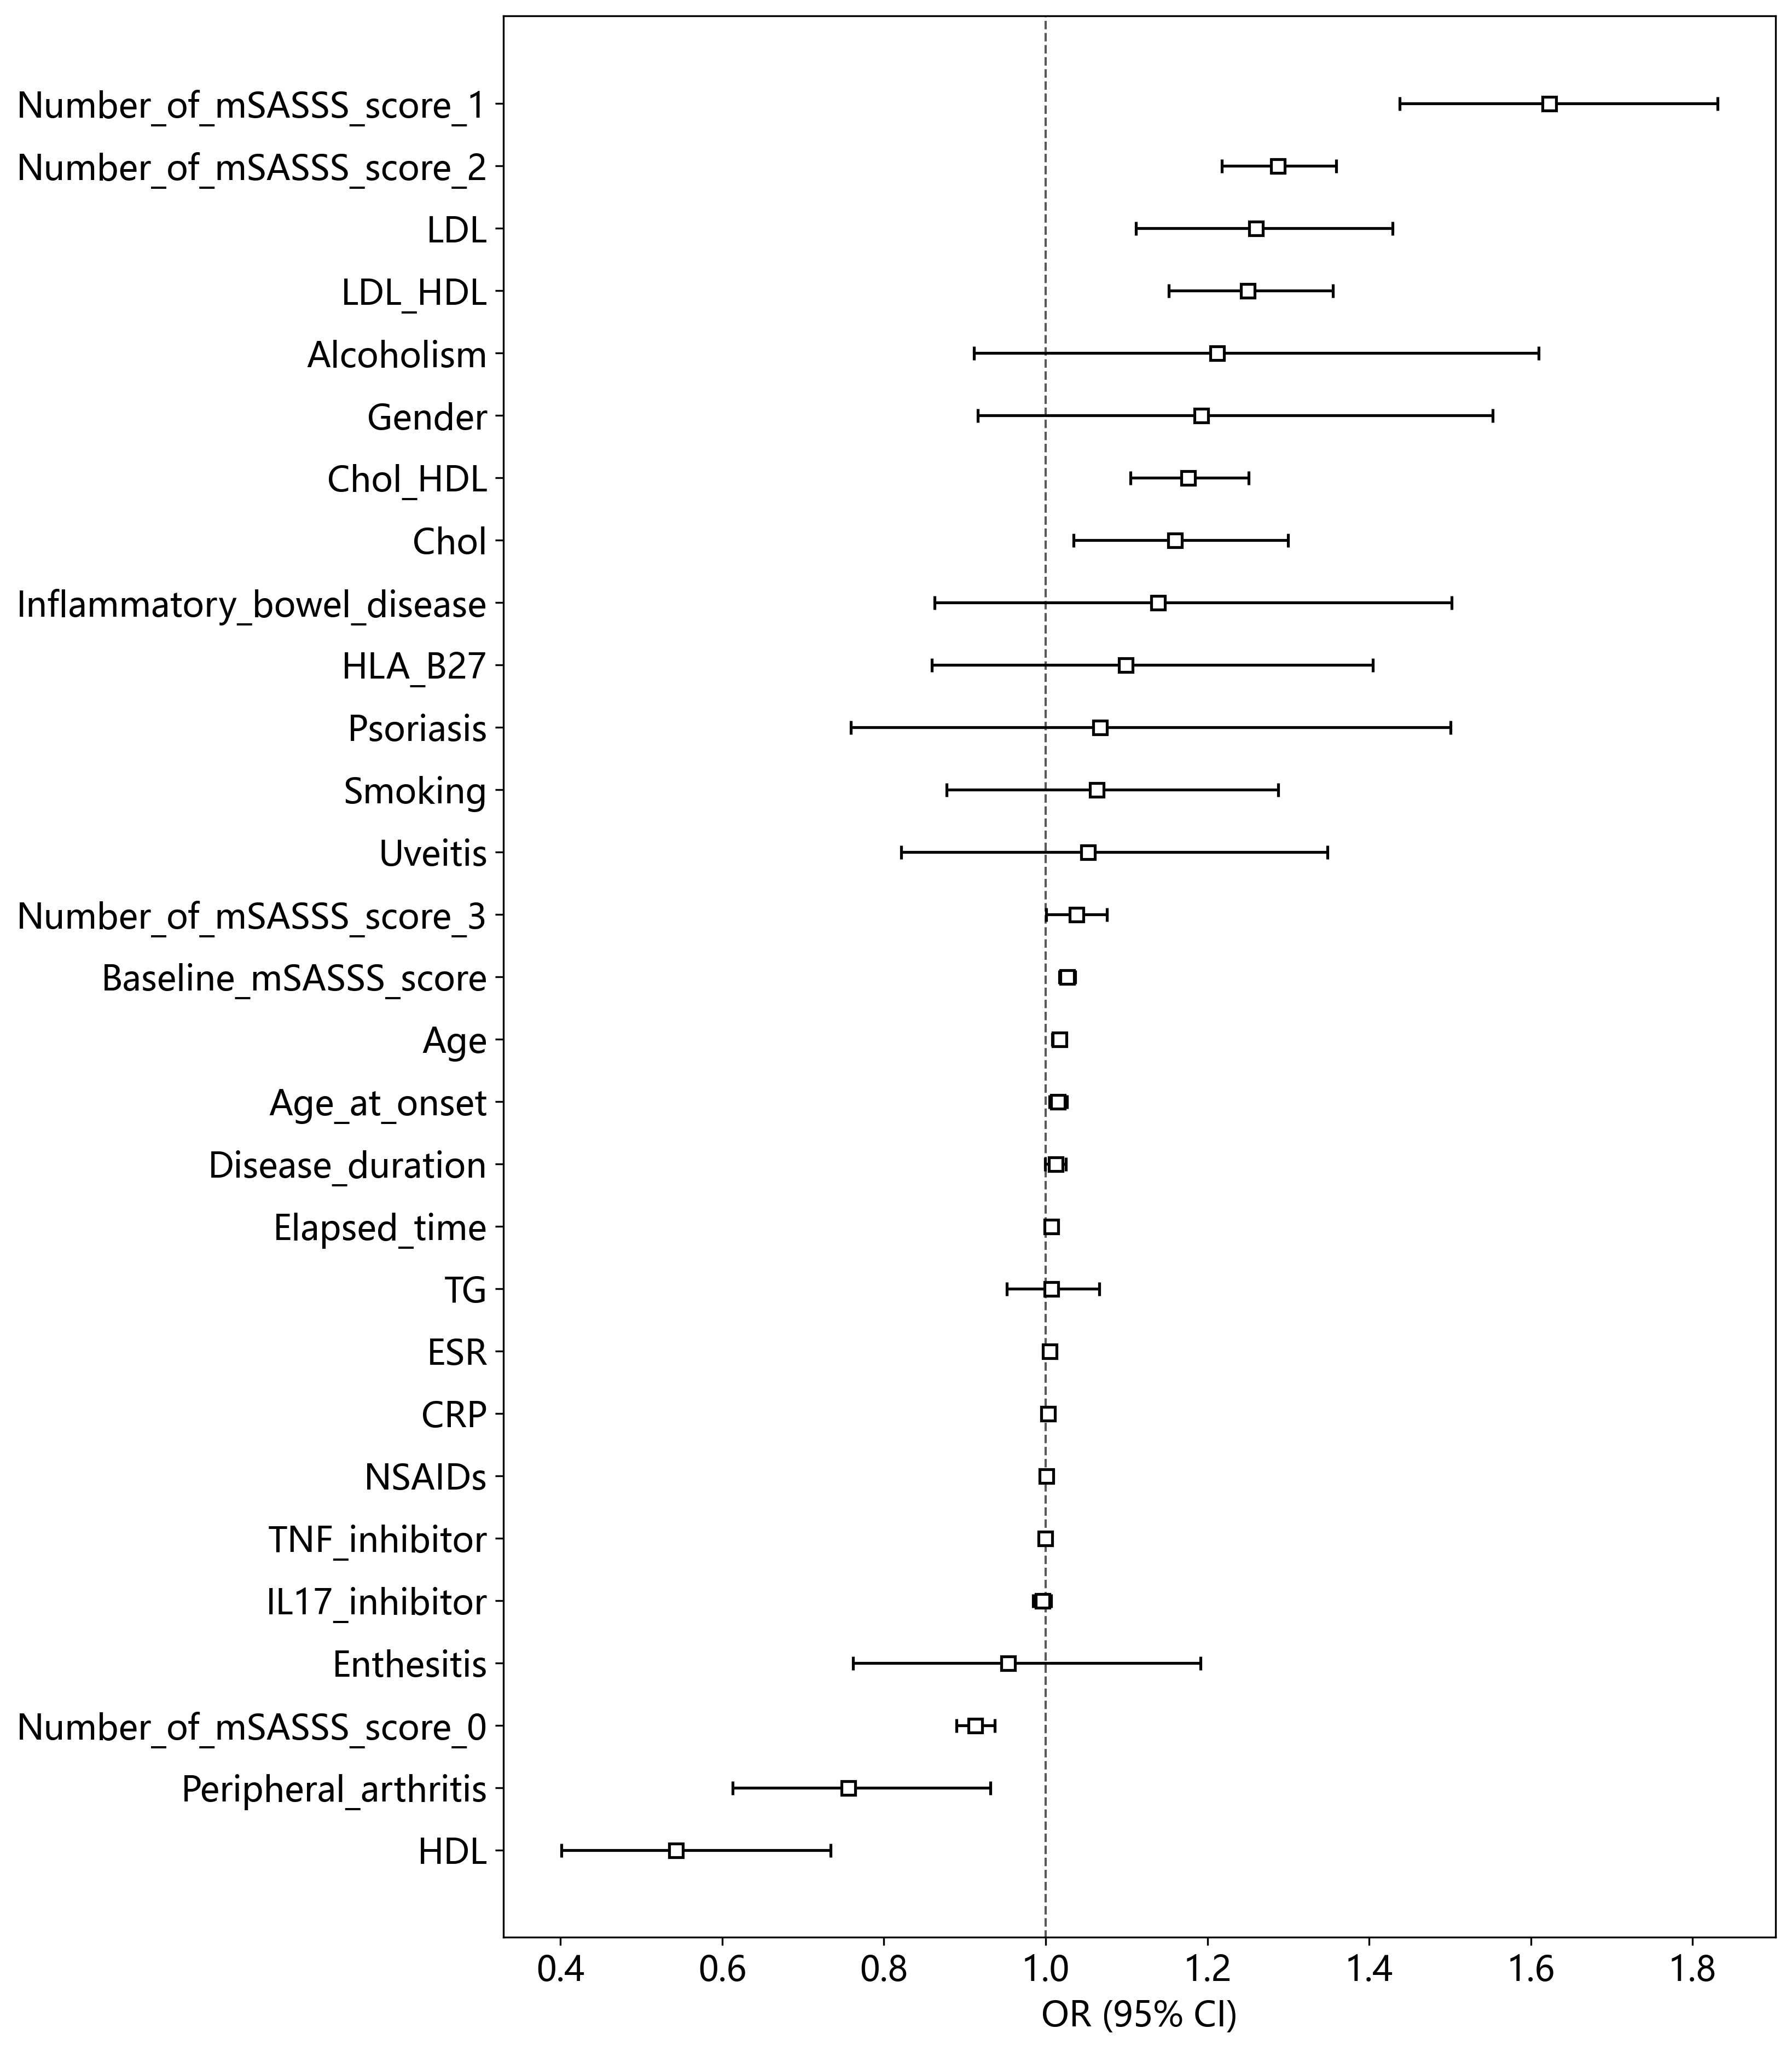

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
HDL,-0.118,-0.697,0.461,0.889,0.498,1.586,0.737
Peripheral_arthritis,-0.212,-0.382,-0.042,0.809,0.682,0.959,0.040
Number_of_mSASSS_score_0,-0.091,-0.200,0.019,0.913,0.819,1.019,0.174
ESR,-0.000,-0.004,0.003,1.000,0.996,1.003,0.836
Elapsed_time,0.008,0.005,0.011,1.008,1.005,1.011,0.000
Age_at_onset,0.006,-0.007,0.018,1.006,0.993,1.018,0.458
Age,-0.005,-0.017,0.006,0.995,0.983,1.006,0.452
Baseline_mSASSS_score,-0.027,-0.065,0.010,0.973,0.937,1.010,0.227
Chol,-0.040,-0.564,0.484,0.961,0.569,1.623,0.900


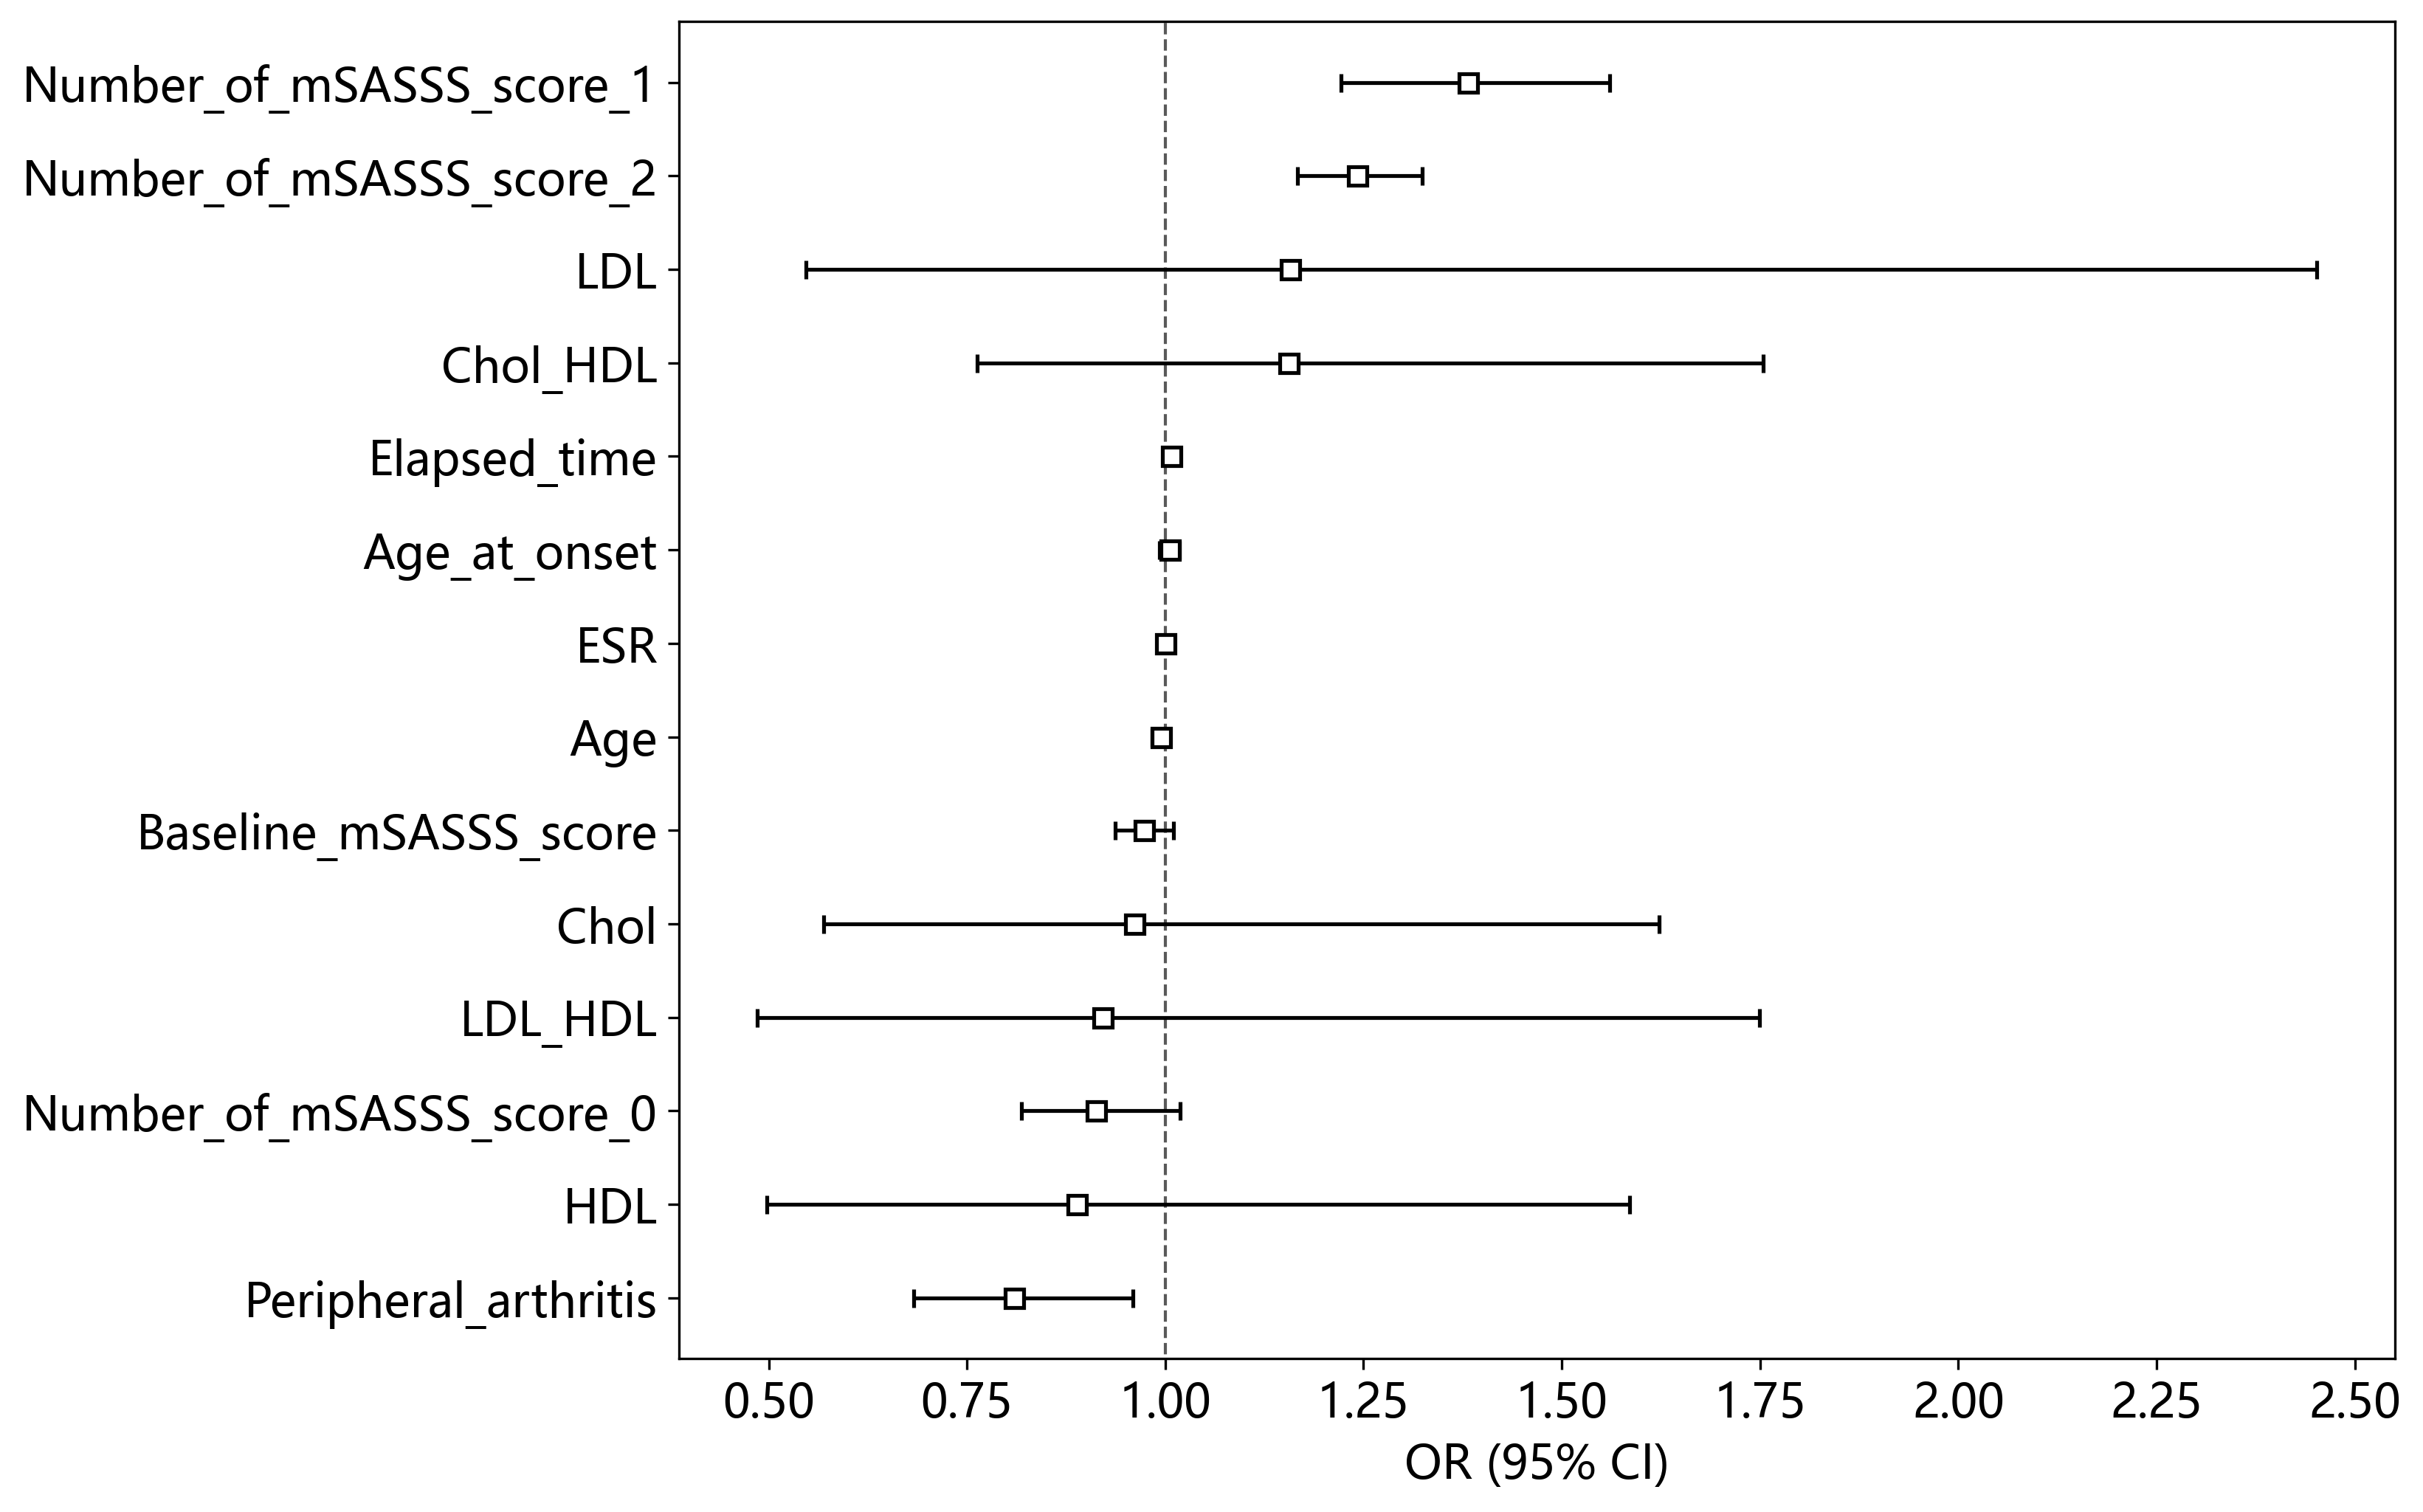

In [11]:
from onekey_algo.custom.components.comp1 import uni_multi_variable_analysis                        

r = uni_multi_variable_analysis(data[data['group'] != '1train'], stats_columns, save_dir='img', p_value4multi=p_value,
                                hazard_ratios=True, label_column=task, algo='ols')

In [12]:
uni_v = pd.read_csv('img/univariable_reg.csv')
uni_v = uni_v[uni_v['p_value'] <= 0.05]
sel_data = data[['ID'] + list(uni_v['feature_name']) + ['group', task]]
# sel_data = data[['ID'] + ['VBED80'] + ['group', task]]
sel_data.to_csv('data/clinic_sel.csv', index=False, encoding='utf-8-sig')
sel_data

,ID,HDL,Peripheral_arthritis,Number_of_mSASSS_score_0,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Chol,Chol_HDL,LDL_HDL,LDL,Number_of_mSASSS_score_2,Number_of_mSASSS_score_1,group,label
0,白璨瑀202003-202501,0.93,1,11.0,54,57,9.0,19,1.2,3.63,3.903,2.301,2.14,0.00,1.0,train,0.000
1,白璨瑀202201-202501,0.96,1,11.0,25,36,9.0,21,1.2,4.09,4.260,2.521,2.42,0.00,1.0,train,0.000
2,边英杰202402-202502,1.19,0,11.0,8,12,28.0,38,1.2,3.49,2.933,1.597,1.90,0.00,1.0,train,0.000
3,曹骥201407-202401,0.69,0,12.0,68,114,16.0,19,0.0,3.40,4.928,1.797,1.24,0.00,0.0,val,2.303
4,常怀城201411-201709,0.76,0,11.5,4,33,27.0,29,0.6,3.04,4.000,2.592,1.97,0.00,0.5,val,0.000
5,陈鹏202405-202505,1.05,0,11.5,22,12,26.0,28,0.6,4.31,4.105,2.533,2.66,0.00,0.5,val,0.000
6,陈强202112-202410,0.68,0,11.5,11,33,28.0,31,0.6,4.54,6.676,4.912,3.34,0.00,0.5,val,0.000
7,陈曦201907-202303,1.07,0,10.0,28,44,21.0,26,3.5,4.63,4.327,2.907,3.11,2.00,0.0,train,1.705
8,程济民202211-202311,0.82,0,0.0,13,12,49.0,65,36.0,4.33,5.280,3.195,2.62,0.00,0.0,train,0.000
9,程佳201306-202508,1.16,0,11.5,8,146,27.5,28,0.6,3.98,3.431,2.328,2.70,0.00,0.5,train,1.649


In [13]:
uni = pd.read_csv('img/univariable_reg.csv')
uni = uni[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
uni['95% CI'] = [f"{y:.4f}-{z:.4f}" for x, y, z in np.array(uni[[c for c in uni.columns if c not in ['feature_name', 'p_value']]])]
multi = pd.read_csv('img/multivariable_reg.csv')
multi = multi[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
multi['95% CI'] = [f"{y:.4f}-{z:.4f}" for x, y, z in np.array(multi[[c for c in multi.columns if c not in ['feature_name', 'p_value']]])]
info = pd.merge(uni[['feature_name', 'OR', '95% CI', 'p_value']], multi[['feature_name' , 'OR', '95% CI', 'p_value']],
                on='feature_name', how='left', suffixes=['_UNI', '_MULTI']).applymap(lambda x: '' if pd.isna(x) else x)
info.to_csv('results/uni_multi_analysis.csv', index=False, encoding='utf-8-sig')
info.applymap(lambda x: x if isinstance(x, str) or x > 0.05 else '<0.05')

,feature_name,OR_UNI,95% CI_UNI,p_value_UNI,OR_MULTI,95% CI_MULTI,p_value_MULTI
0,HDL,0.543,0.4010-0.7340,<0.05,0.889,0.4980-1.5860,0.737
1,Peripheral_arthritis,0.756,0.6130-0.9310,<0.05,0.809,0.6820-0.9590,<0.05
2,Number_of_mSASSS_score_0,0.913,0.8900-0.9370,<0.05,0.913,0.8190-1.0190,0.174
3,Enthesitis,0.953,0.7620-1.1910,0.722,,,
4,IL17_inhibitor,0.996,0.9840-1.0070,0.5,,,
5,TNF_inhibitor,0.999,0.9940-1.0040,0.762,,,
6,NSAIDs,1.001,0.9990-1.0030,0.499,,,
7,CRP,1.003,0.9990-1.0060,0.164,,,
8,ESR,1.005,1.0010-1.0090,<0.05,1.0,0.9960-1.0030,0.836
9,TG,1.007,0.9520-1.0660,0.832,,,
